In [5]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import scipy as sp
import scipy.io.wavfile as wf
import librosa
import librosa.display
import IPython.display as ipd
import os
import soundfile as sf
import lightgbm
%matplotlib inline
from itertools import cycle
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import to_categorical

np.random.seed(4)

In [2]:
def extract_features(file_path, max_pad_len=174):
    try:
        # Load the audio file
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
        # Extract 40 MFCC features
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        # Pad or truncate the MFCCs to have a fixed length
        if mfccs.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]
        return mfccs
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [3]:
# Read the CSV file
train_df = pd.read_csv('development.csv')

# Create the 'intention' column by combining 'action' and 'object'
train_df['intention'] = train_df.pop('action') + train_df.pop('object')

# Update the 'path' column to include the full directory path
train_df['path'] = 'D:/Data Science and Engineering/Datasets/' + train_df['path']

features = []
labels = []

# Iterate over each row in the DataFrame
for index, row in train_df.iterrows():
    file_path = row['path']
    intent = row['intention']
    mfcc = extract_features(file_path)
    if mfcc is not None:
        features.append(mfcc)
        labels.append(intent)

features = np.array(features)
labels = np.array(labels)
print('Features shape:', features.shape)
print('Labels shape:', labels.shape)

c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


Features shape: (9854, 40, 174)
Labels shape: (9854,)


In [ ]:
le = LabelEncoder()
y = le.fit_transform(labels)
y = to_categorical(y)

# Add channel dimension for CNN input
features = features[..., np.newaxis]

# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (7883, 40, 174, 1)
y_train shape: (7883, 7)
X_test shape: (1971, 40, 174, 1)
y_test shape: (1971, 7)


In [7]:
input_shape = X_train.shape[1:]

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(y_train.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,752,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,772,359 (10.58 MB)

 Trainable params: 2,772,359 (10.58 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.2337 - loss: 4.8776 - val_accuracy: 0.2816 - val_loss: 1.7979
Epoch 2/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.2976 - loss: 1.7490 - val_accuracy: 0.3404 - val_loss: 1.6501
Epoch 3/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.3334 - loss: 1.6287 - val_accuracy: 0.3699 - val_loss: 1.5441
Epoch 4/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.3637 - loss: 1.5613 - val_accuracy: 0.4054 - val_loss: 1.4429
Epoch 5/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.3774 - loss: 1.4854 - val_accuracy: 0.4145 - val_loss: 1.4294
Epoch 6/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.4161 - loss: 1.4170 - val_accuracy: 0.4333 - val_loss: 1.3931
Epoch 7/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.4505 - loss: 1.3293 - val_accuracy: 0.4404 - val_loss: 1.3549
Epoch 8/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.4826 - loss: 1.2533 - 

Test loss: 1.7965036630630493
Test accuracy: 0.5347539186477661


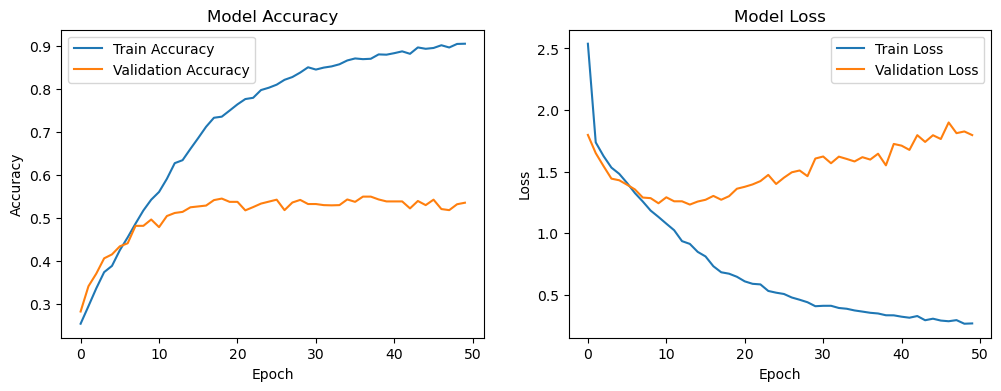

In [9]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# Plot the training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [10]:
def predict_intent(file_path):
    feature = extract_features(file_path)
    if feature is not None:
        # Reshape feature to match the input dimensions of the model
        feature = feature[np.newaxis, ..., np.newaxis]
        prediction = model.predict(feature)
        predicted_index = np.argmax(prediction)
        predicted_intent = le.inverse_transform([predicted_index])[0]
        return predicted_intent
    else:
        return None

# Example usage:
# Replace 'path_to_audio.wav' with the path to your audio file
# print('Predicted Intent:', predict_intent('path_to_audio.wav'))